<a href="https://colab.research.google.com/github/abiduldul/Komputasi-Numeris/blob/main/Materi%201/Newton_Raphson_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Newton-Raphson Method**

Iter |     x        |     y        |   ||F||
-------------------------------------------------------
   1 |     0.000000 |     0.000000 | 1.000000e+00
   2 |    -1.000000 |     0.000000 | 1.414214e+00
   3 |    -0.600000 |     0.200000 | 1.788854e-01
   4 |    -0.528682 |     0.196899 | 7.179435e-03
   5 |    -0.525692 |     0.197965 | 1.115515e-05
   6 |    -0.525687 |     0.197966 | 3.144880e-11

Converged Solution:
x = -0.525687
y = 0.197966


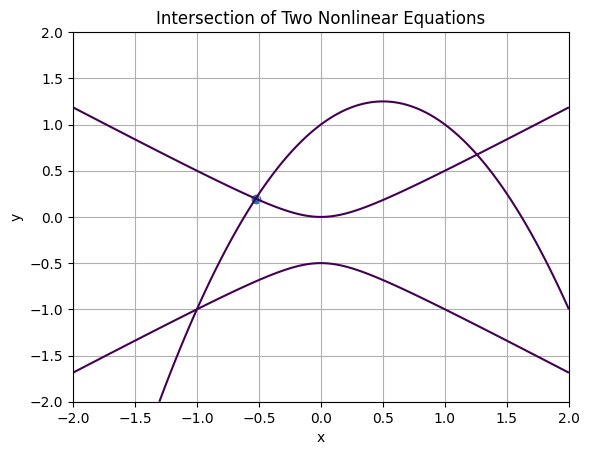

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def F(x, y):
    f1 = y + x**2 - 1 - x
    f2 = x**2 - 2*y**2 - y
    return np.array([f1, f2])

def J(x, y):
    return np.array([
        [2*x - 1, 1],
        [2*x, -4*y - 1]
    ])

x = 0.0
y = 0.0

tol = 1e-6
max_iter = 20

print("Iter |     x        |     y        |   ||F||")
print("-"*55)

for i in range(1, max_iter+1):

    F_val = F(x, y)
    J_val = J(x, y)

    # Solve J * delta = F
    delta = np.linalg.solve(J_val, F_val)

    x_new = x - delta[0]
    y_new = y - delta[1]

    error = np.linalg.norm(F_val)

    print(f"{i:4d} | {x:12.6f} | {y:12.6f} | {error:10.6e}")

    if error < tol:
        break

    x, y = x_new, y_new

print("\nConverged Solution:")
print(f"x = {x:.6f}")
print(f"y = {y:.6f}")

# Plot the intersection of the two nonlinear equations
x_vals = np.linspace(-2, 2, 400)
y_vals = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x_vals, y_vals)

F1 = Y + X**2 - 1 - X
F2 = X**2 - 2*Y**2 - Y

plt.figure()
plt.contour(X, Y, F1, levels=[0])
plt.contour(X, Y, F2, levels=[0])

plt.scatter(x, y)
plt.title("Intersection of Two Nonlinear Equations")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()